In [7]:
import os
import pandas as pd
from fuzzywuzzy import process

df = pd.read_csv("researchers.csv", usecols=["Name", "Google Scholar ID"])
display(df.isna().value_counts())
display(df)

pulled_researchers = os.listdir("Papers")

all_researchers = list(df["Name"].values)


def find_matches_and_missing(pulled, all_names, threshold=80):
    matched = {}
    missing = []

    for name in all_names:
        best_match = process.extractOne(name, pulled)
        if best_match and best_match[1] >= threshold:
            matched[name] = best_match[0]
        else:
            missing.append(name)

    return matched, missing


# Usage
matched, missing = find_matches_and_missing(pulled_researchers, all_researchers)
print("Matched:", matched)
print("Missing:", missing)

Name   Google Scholar ID
False  False                62
Name: count, dtype: int64

,Name,Google Scholar ID
0,Michael Osborne,iTNcAakAAAAJ
1,Alex Rogers,0Z4sWCoAAAAJ
2,Alessandro Abate,yskbfM4AAAAJ
3,Wes Armour,0cuZV8gAAAAJ
4,Fazl Barez,EAjpNIMAAAAJ
...,...,...
57,Michael Wooldridge,JD8v9fkAAAAJ
58,Nobuko Yoshida,4T-p76AAAAAJ
59,Tingting Zhu,fjGMIl0AAAAJ
60,Noa Zilberman,DDsHGFwAAAAJ


Matched: {'Michael Osborne': 'Michael A Osborne', 'Alex Rogers': 'Alex Rogers', 'Alessandro Abate': 'Alessandro Abate', 'Wes Armour': 'Wes Armour', 'Fazl Barez': 'Fazl Barez', 'Atilim Gunes Baydin': 'Atılım Güneş Baydin', 'Adel Bibi': 'Adel Bibi', 'Simon Birnbach': 'Simon Birnbach', 'Michael Bronstein': 'Michael Bronstein', 'Ronald Clark': 'Ronald Clark', 'Jan-Peter Calliess': 'Jan-Peter Calliess', 'Giuseppe De Giacomo': 'Giuseppe De Giacomo', 'Daniele De Martini': 'Daniele De Martini', 'Xiaowen Dong': 'Xiaowen Dong', 'Stephen Duncan': 'Stephen R Duncan', 'Maurice Fallon': 'Maurice Fallon', 'Seth Flaxman': 'Seth Flaxman', 'Jakob Foerster': 'Jakob Foerster', 'Luca Furieri': 'Luca Furieri', 'Yarin Gal': 'Yarin Gal', 'Jonathan Gammell': 'Jonathan Gammell', 'Jiarui Gan': 'Jiarui Gan', 'Paul Goulart': 'Paul Goulart', 'Jindong Gu': 'Jindong Gu', 'Ioannis Havoutis': 'Ioannis Havoutis', 'Jo�o Henriques': 'João F. Henriques', 'Nick Hawes': 'Nick Hawes', 'Konstantinos Kamnitsas': 'Konstantinos K

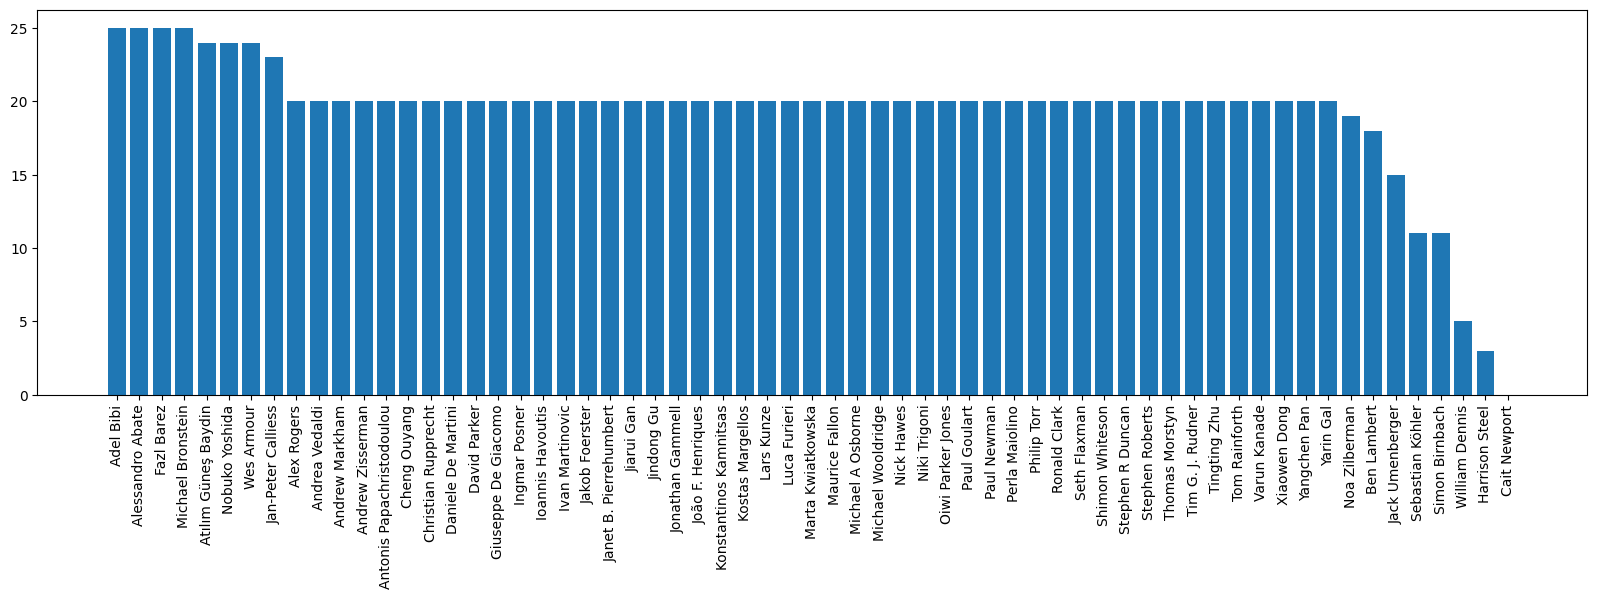

In [8]:
import os
import matplotlib.pyplot as plt

n_papers = []
for author in pulled_researchers:
    papers = os.listdir(os.path.join("Papers", author))
    n_papers.append(len(papers))

# sort by n_papers
authors_sorted, n_papers_sorted = zip(
    *sorted(zip(pulled_researchers, n_papers), key=lambda x: x[1], reverse=True)
)

plt.figure(figsize=(20, 5))
plt.bar(authors_sorted, n_papers_sorted)
plt.xticks(rotation=90)
plt.show()

In [9]:
import subprocess

for author in pulled_researchers:
    if author == "William Dennis":
        continue

    print("Processing", author)

    try:
        print("Adding....")
        subprocess.run(
            ["git", "add", f"Papers/{author}"],
            check=True
        )

        print("Committing....")
        # commit may fail if nothing changed
        subprocess.run(
            ["git", "commit", "-m", author],
            check=True
        )

        print("Pushing....")
        subprocess.run(
            ["git", "push"],
            check=True
        )

    except subprocess.CalledProcessError as e:
        print(f"Skipped {author}: {e}")


Processing Adel Bibi
Adding....
Committing....
Pushing....
Processing Alessandro Abate
Adding....
Committing....
Pushing....
Processing Alex Rogers
Adding....
Committing....
Pushing....
Processing Andrea Vedaldi
Adding....
Committing....
Pushing....
Processing Andrew Markham
Adding....
Committing....
Pushing....
Processing Andrew Zisserman
Adding....
Committing....
Pushing....
Processing Antonis Papachristodoulou
Adding....
Committing....
Pushing....
Processing Atılım Güneş Baydin
Adding....
Committing....
Pushing....
Processing Ben Lambert
Adding....
Committing....
Pushing....
Processing Cait Newport
Adding....
Committing....
Skipped Cait Newport: Command '['git', 'commit', '-m', 'Cait Newport']' returned non-zero exit status 1.
Processing Cheng Ouyang
Adding....
Committing....
Pushing....
Processing Christian Rupprecht
Adding....
Committing....
Pushing....
Processing Daniele De Martini
Adding....
Committing....
Pushing....
Processing David Parker
Adding....
Committing....
Pushing....